In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_sme_financial_dataset.csv")

df.head()

,transaction_id,invoice_date,store_id,region,store_type,customer_id,customer_segment,product_id,product_category,quantity,...,net_profit,payment_method,cash_collection_date,expense_payment_date,cash_inflow,cash_outflow,net_cash_flow,is_return,holiday_flag,oil_price_index
0,2316,2022-01-01,14,West,B,705.0,Regular,74,Beverages,2,...,69.23,Card,2022-01-04,2022-01-31,353.60,284.37,69.23,0,0,77.75
1,3674,2022-01-01,21,North,A,7689.0,Wholesale,11,Household,10,...,1803.37,Card,2022-01-01,2022-01-01,6456.71,4653.33,1803.38,0,0,79.72
2,5083,2022-01-01,10,Central,B,7351.0,Regular,38,Clothing,2,...,687.74,Card,2022-01-01,2022-01-01,1663.76,976.02,687.74,0,0,76.06
3,6302,2022-01-01,21,North,A,469.0,Regular,21,Electronics,3,...,481.69,Credit,2022-01-16,2022-01-01,6281.71,5800.02,481.69,0,0,75.09
4,7006,2022-01-01,14,West,B,3525.0,Regular,131,Household,2,...,218.14,UPI,2022-01-01,2022-01-01,818.61,600.46,218.15,0,0,76.31


In [2]:
financial_summary = {
    "Total Revenue": df["revenue"].sum(),
    "Total COGS": df["cogs"].sum(),
    "Total Gross Profit": df["gross_profit"].sum(),
    "Total Operating Expense": df["operating_expense"].sum(),
    "Total Net Profit": df["net_profit"].sum(),
    "Total Cash Inflow": df["cash_inflow"].sum(),
    "Total Cash Outflow": df["cash_outflow"].sum(),
    "Total Net Cash Flow": df["net_cash_flow"].sum()
}

for metric, value in financial_summary.items():
    print(f"{metric}: ${value:,.2f}")

gross_margin = (
    df["gross_profit"].sum() / df["revenue"].sum()
) * 100

net_margin = (
    df["net_profit"].sum() / df["revenue"].sum()
) * 100

print(f"\nGross Profit Margin: {gross_margin:.2f}%")
print(f"Net Profit Margin: {net_margin:.2f}%")

Total Revenue: $469,437,492.83
Total COGS: $339,893,597.31
Total Gross Profit: $129,543,894.93
Total Operating Expense: $36,001,339.08
Total Net Profit: $93,542,555.88
Total Cash Inflow: $468,229,509.03
Total Cash Outflow: $379,748,542.55
Total Net Cash Flow: $88,480,966.48

Gross Profit Margin: 27.60%
Net Profit Margin: 19.93%


In [3]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

monthly_financials = (
    df.groupby(df["invoice_date"].dt.to_period("M"))
      .agg({
          "revenue": "sum",
          "gross_profit": "sum",
          "net_profit": "sum"
      })
      .reset_index()
)

monthly_financials["invoice_date"] = monthly_financials["invoice_date"].dt.to_timestamp()

monthly_financials.head()

,invoice_date,revenue,gross_profit,net_profit
0,2022-01-01,13844780.66,3817793.98,2753599.91
1,2022-02-01,12538027.81,3553823.91,2596404.44
2,2022-03-01,14531335.59,3979926.30,2865458.70
3,2022-04-01,13708966.43,3778825.02,2726114.17
4,2022-05-01,13265596.77,3610114.72,2589126.71


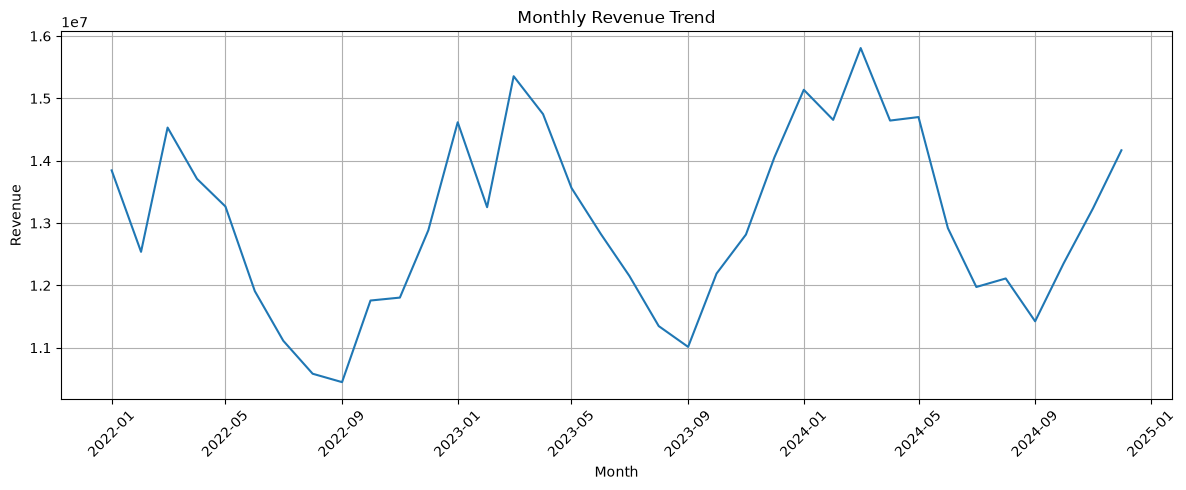

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

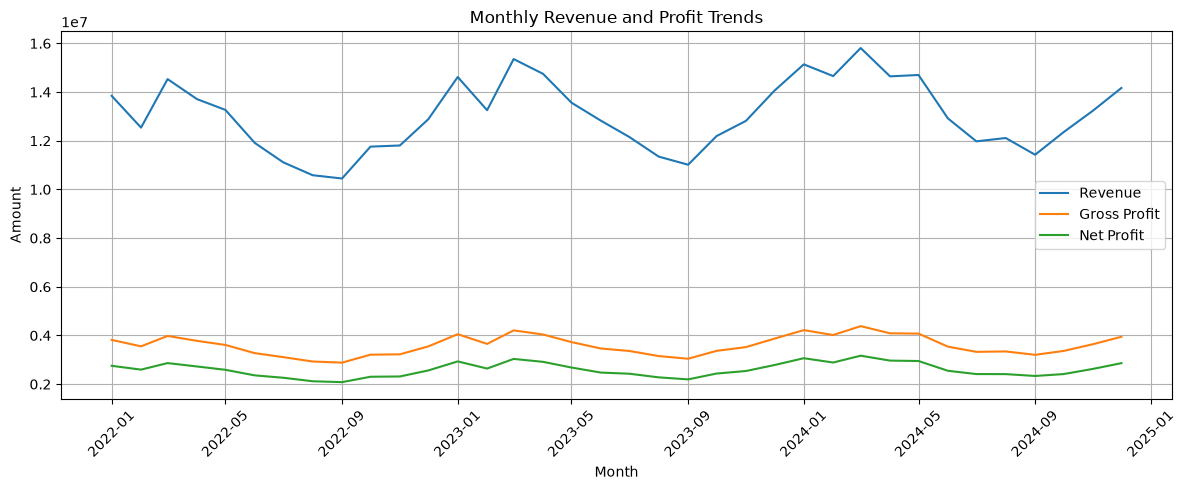

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["revenue"],
    label="Revenue"
)

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["gross_profit"],
    label="Gross Profit"
)

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["net_profit"],
    label="Net Profit"
)

plt.title("Monthly Revenue and Profit Trends")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [6]:
monthly_financials["gross_margin"] = (
    monthly_financials["gross_profit"]
    / monthly_financials["revenue"]
) * 100

monthly_financials["net_margin"] = (
    monthly_financials["net_profit"]
    / monthly_financials["revenue"]
) * 100

monthly_financials.head()

,invoice_date,revenue,gross_profit,net_profit,gross_margin,net_margin
0,2022-01-01,13844780.66,3817793.98,2753599.91,27.575691,19.889083
1,2022-02-01,12538027.81,3553823.91,2596404.44,28.344361,20.708236
2,2022-03-01,14531335.59,3979926.30,2865458.70,27.388579,19.719170
3,2022-04-01,13708966.43,3778825.02,2726114.17,27.564624,19.885629
4,2022-05-01,13265596.77,3610114.72,2589126.71,27.214115,19.517604


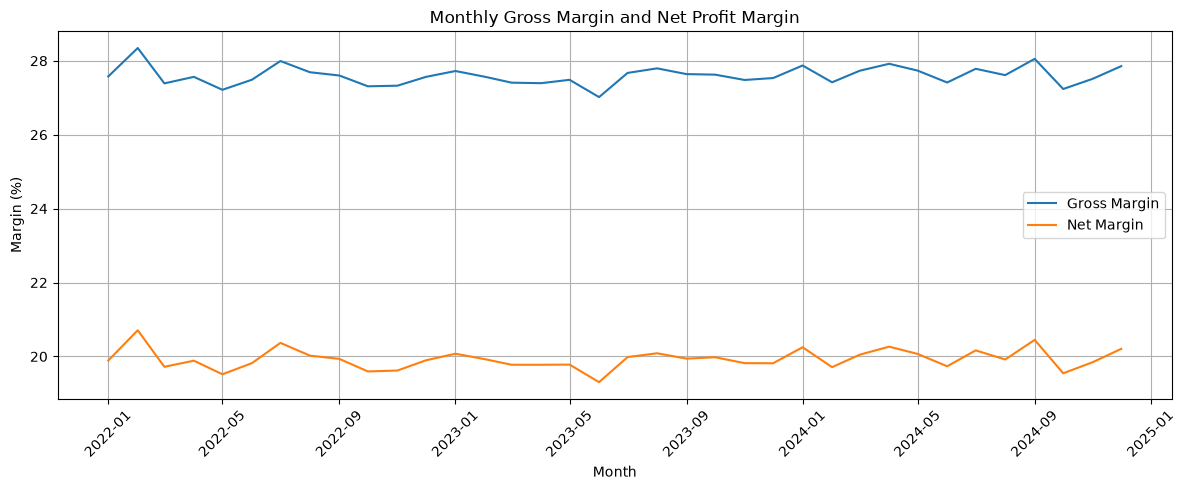

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["gross_margin"],
    label="Gross Margin"
)

plt.plot(
    monthly_financials["invoice_date"],
    monthly_financials["net_margin"],
    label="Net Margin"
)

plt.title("Monthly Gross Margin and Net Profit Margin")
plt.xlabel("Month")
plt.ylabel("Margin (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [8]:
region_revenue = (
    df.groupby("region")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(region_revenue)

region
South      96825016.15
Central    93528166.88
West       93336258.84
East       93191269.41
North      92556781.55
Name: revenue, dtype: float64


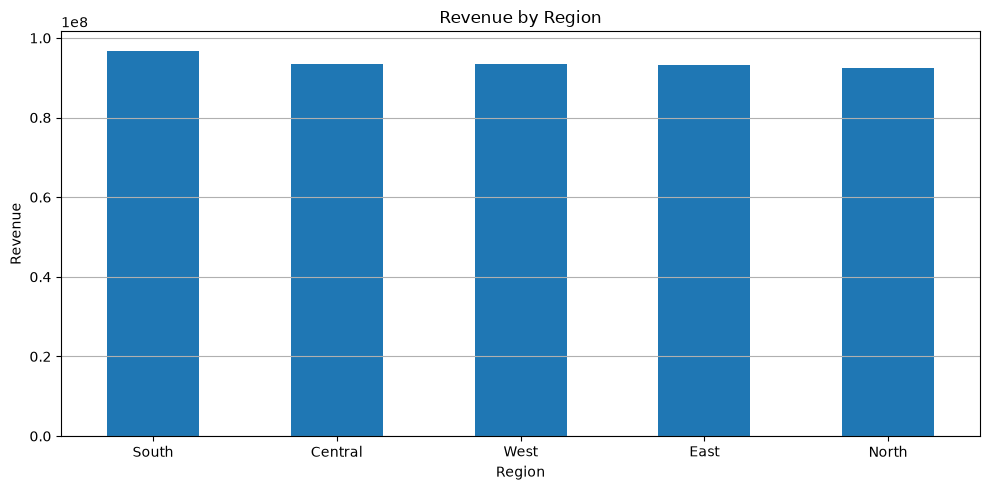

In [9]:
plt.figure(figsize=(10, 5))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [10]:
region_profit = (
    df.groupby("region")[["revenue", "gross_profit", "net_profit"]]
      .sum()
      .sort_values("net_profit", ascending=False)
)

print(region_profit)

             revenue  gross_profit   net_profit
region                                         
South    96825016.15   26718246.74  19306996.34
West     93336258.84   25810343.70  18665811.88
Central  93528166.88   25754341.32  18571878.91
East     93191269.41   25712505.80  18544303.41
North    92556781.55   25548457.37  18453565.34


In [11]:
region_profit["gross_margin"] = (
    region_profit["gross_profit"] / region_profit["revenue"]
) * 100

region_profit["net_margin"] = (
    region_profit["net_profit"] / region_profit["revenue"]
) * 100

print(region_profit)

             revenue  gross_profit   net_profit  gross_margin  net_margin
region                                                                   
South    96825016.15   26718246.74  19306996.34     27.594363   19.940091
West     93336258.84   25810343.70  18665811.88     27.653073   19.998457
Central  93528166.88   25754341.32  18571878.91     27.536455   19.856990
East     93191269.41   25712505.80  18544303.41     27.591110   19.899185
North    92556781.55   25548457.37  18453565.34     27.603010   19.937562


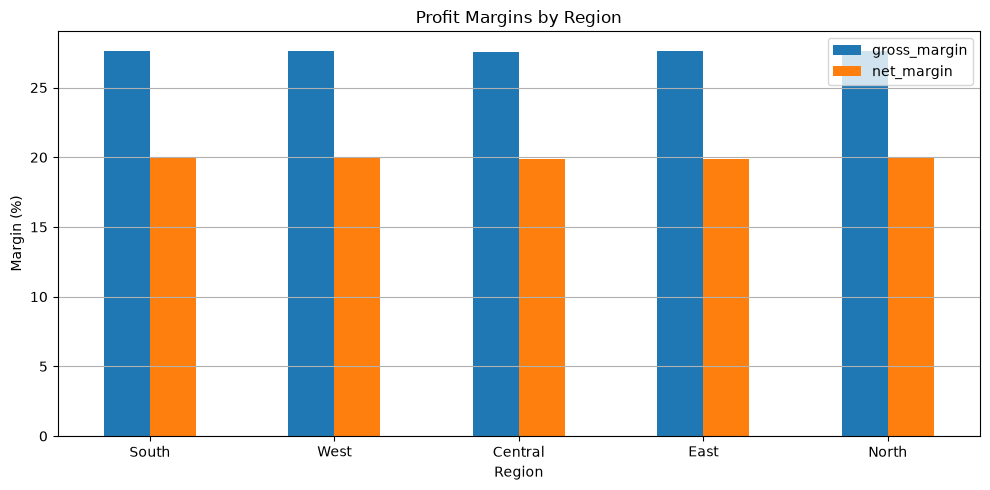

In [12]:
region_profit[["gross_margin", "net_margin"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Profit Margins by Region")
plt.xlabel("Region")
plt.ylabel("Margin (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [13]:
store_performance = (
    df.groupby("store_type")[["revenue", "gross_profit", "net_profit"]]
      .sum()
      .sort_values("revenue", ascending=False)
)

store_performance["gross_margin"] = (
    store_performance["gross_profit"]
    / store_performance["revenue"]
) * 100

store_performance["net_margin"] = (
    store_performance["net_profit"]
    / store_performance["revenue"]
) * 100

print(store_performance)

                 revenue  gross_profit   net_profit  gross_margin  net_margin
store_type                                                                   
A           1.319692e+08   36427198.56  26310312.53     27.602799   19.936704
B           1.130923e+08   31139195.28  22455435.02     27.534324   19.855851
C           1.126912e+08   31083036.25  22437812.21     27.582496   19.910888
D           1.116848e+08   30894464.84  22338996.12     27.662186   20.001818


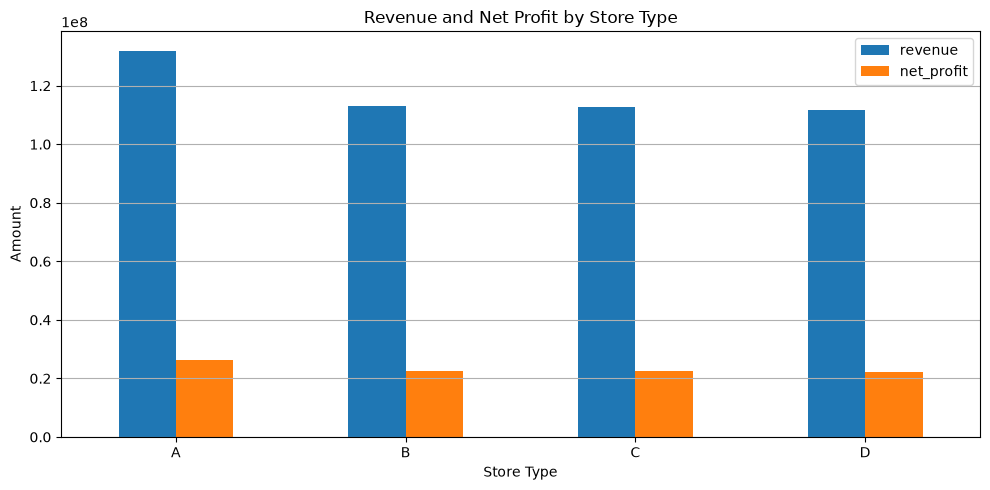

In [14]:
store_performance[["revenue", "net_profit"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue and Net Profit by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [15]:
category_performance = (
    df.groupby("product_category")[["revenue", "gross_profit", "net_profit"]]
      .sum()
      .sort_values("revenue", ascending=False)
)

category_performance["gross_margin"] = (
    category_performance["gross_profit"]
    / category_performance["revenue"]
) * 100

category_performance["net_margin"] = (
    category_performance["net_profit"]
    / category_performance["revenue"]
) * 100

print(category_performance)

                       revenue  gross_profit   net_profit  gross_margin  \
product_category                                                          
Electronics       1.820293e+08   32754719.70  16555937.90     17.994199   
Clothing          7.987849e+07   35499495.16  29979832.28     44.441872   
Pharmacy          5.514528e+07   13786428.48   9998631.00     25.000198   
Personal Care     4.746058e+07   18035725.99  14766347.37     38.001488   
Household         4.406251e+07   14105430.46  11071517.33     32.012320   
Grocery           2.589027e+07    5177389.72   3392637.13     19.997436   
Stationery        1.988130e+07    5960493.14   4592598.37     29.980399   
Beverages         1.508975e+07    4224212.28   3185054.50     27.993926   

                  net_margin  
product_category              
Electronics         9.095203  
Clothing           37.531798  
Pharmacy           18.131437  
Personal Care      31.112869  
Household          25.126844  
Grocery            13.103909  
S

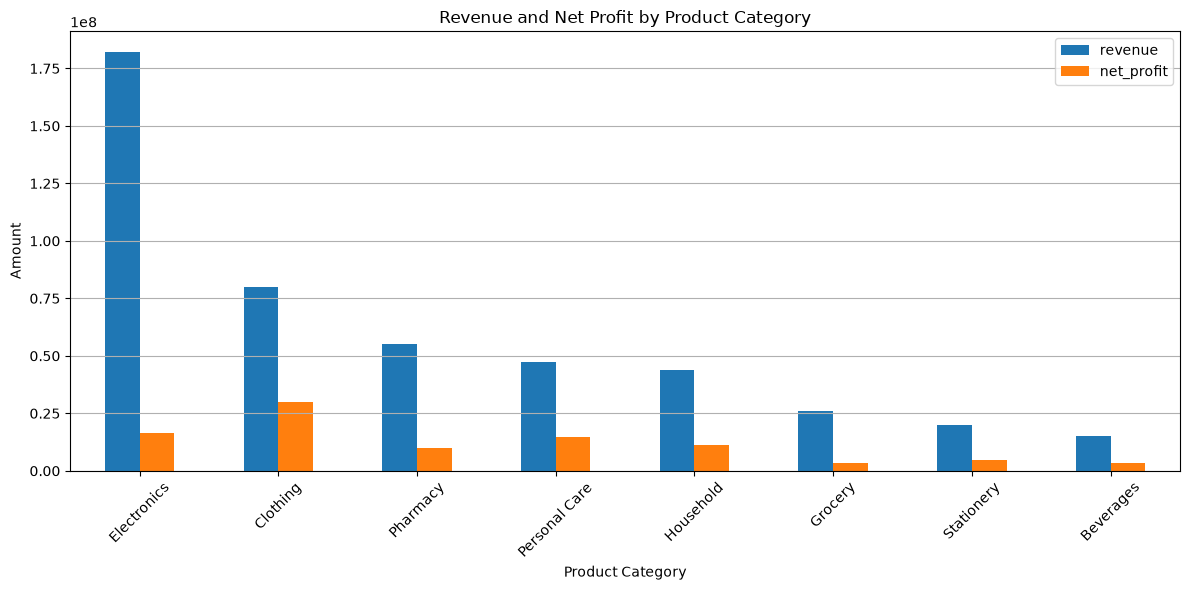

In [16]:
category_performance[["revenue", "net_profit"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue and Net Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

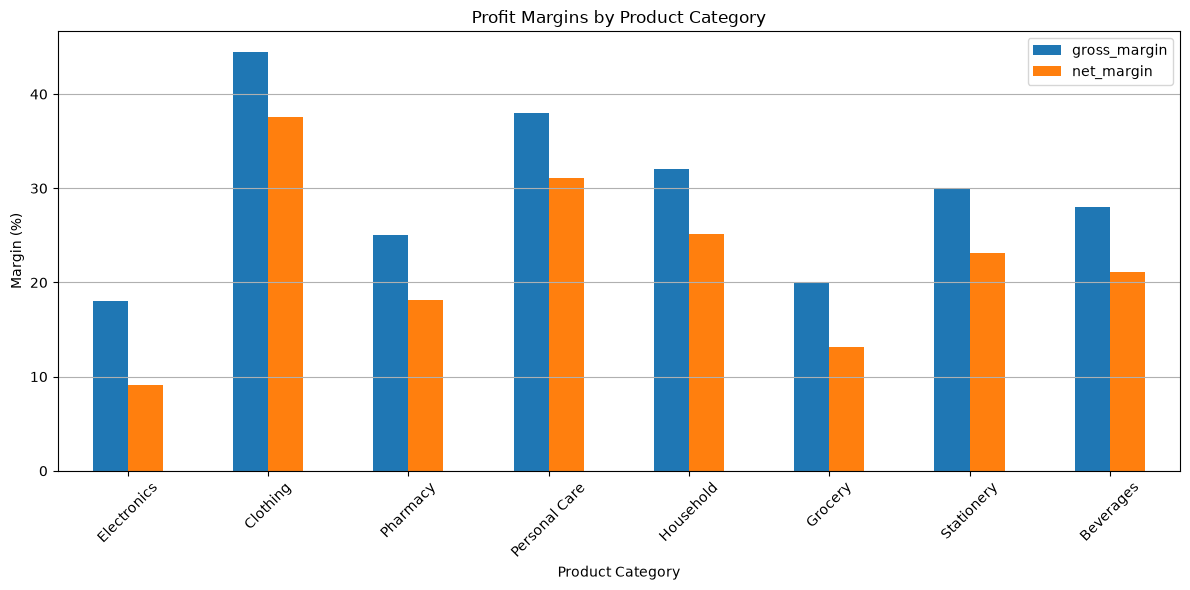

In [17]:
category_performance[["gross_margin", "net_margin"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Profit Margins by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Margin (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [18]:
customer_segment_performance = (
    df.groupby("customer_segment")[["revenue", "gross_profit", "net_profit"]]
      .sum()
      .sort_values("revenue", ascending=False)
)

customer_segment_performance["gross_margin"] = (
    customer_segment_performance["gross_profit"]
    / customer_segment_performance["revenue"]
) * 100

customer_segment_performance["net_margin"] = (
    customer_segment_performance["net_profit"]
    / customer_segment_performance["revenue"]
) * 100

print(customer_segment_performance)

                       revenue  gross_profit   net_profit  gross_margin  \
customer_segment                                                          
Regular           1.992468e+08   54941053.72  39163588.14     27.574373   
New               1.159135e+08   32062137.30  22886859.62     27.660402   
Wholesale         7.818873e+07   21615335.84  16594937.42     27.645078   
Premium           7.608848e+07   20925368.07  14897170.70     27.501361   

                  net_margin  
customer_segment              
Regular            19.655819  
New                19.744777  
Wholesale          21.224206  
Premium            19.578746  


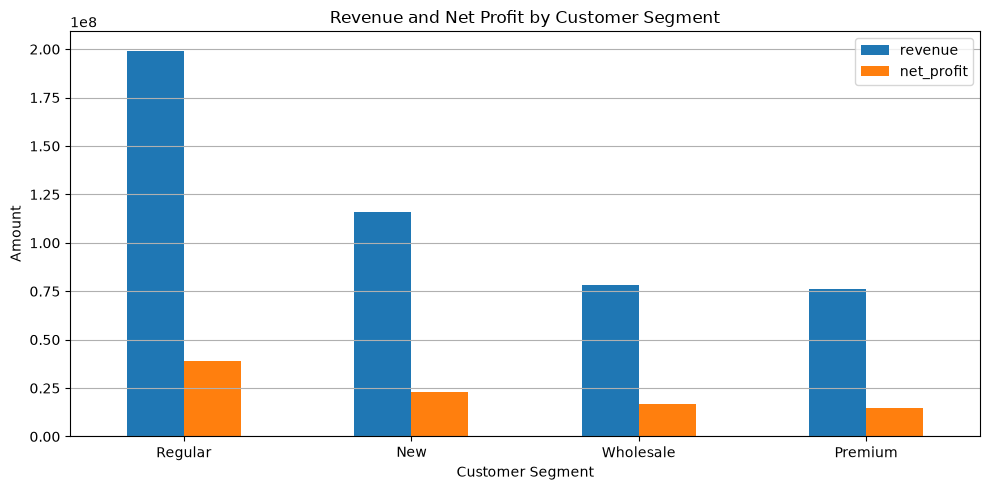

In [19]:
customer_segment_performance[["revenue", "net_profit"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue and Net Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

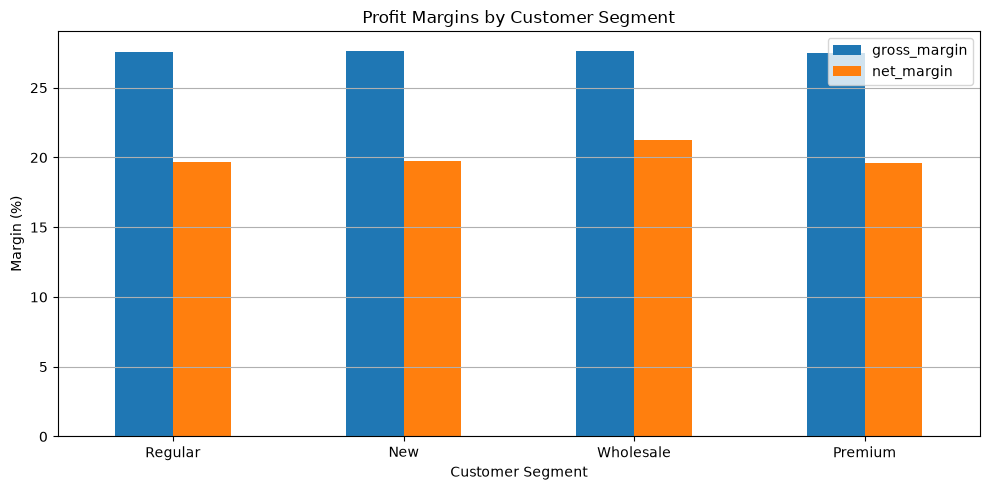

In [20]:
customer_segment_performance[["gross_margin", "net_margin"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Profit Margins by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Margin (%)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [21]:
quantity_revenue = (
    df.groupby("quantity")["revenue"]
      .agg(["sum", "mean", "count"])
      .reset_index()
)

quantity_revenue.columns = [
    "quantity",
    "total_revenue",
    "average_revenue",
    "transaction_count"
]

print(quantity_revenue)

    quantity  total_revenue  average_revenue  transaction_count
0          1    13609458.15       527.887132              25781
1          2    59339162.17      1049.507644              56540
2          3    99294618.38      1576.480406              62985
3          4    97096421.31      2099.654470              46244
4          5    68851164.22      2624.201098              26237
5          6    40652078.05      3120.362147              13028
6          7    22082210.49      3667.532053               6021
7          8    13717497.52      4115.660822               3333
8          9    11990975.32      4765.888442               2516
9         10    12740766.84      5461.108804               2333
10        11    11072579.89      5722.263509               1935
11        12     8591965.98      6221.553932               1381
12        13     5532064.32      6771.192558                817
13        14     3121258.16      7803.145400                400
14        15     1745272.03      5722.20

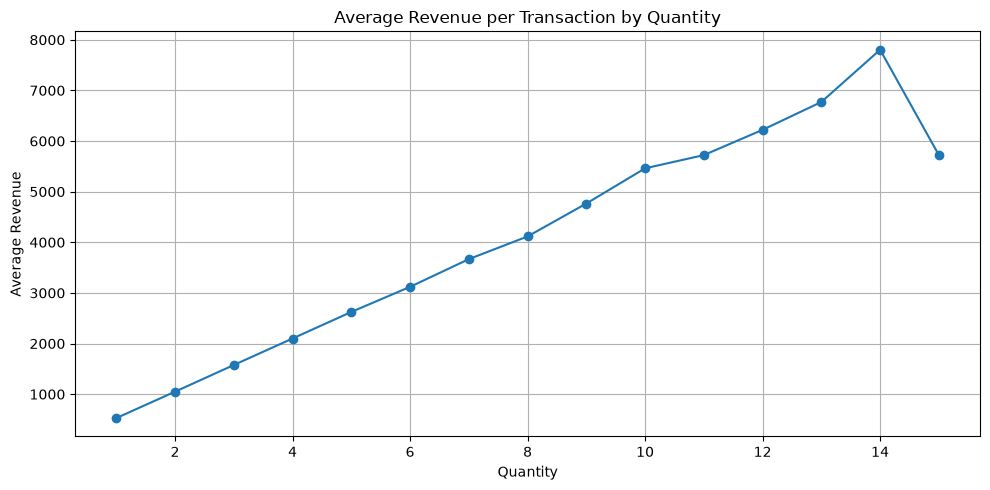

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    quantity_revenue["quantity"],
    quantity_revenue["average_revenue"],
    marker="o"
)

plt.title("Average Revenue per Transaction by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Average Revenue")
plt.grid(True)
plt.tight_layout()

plt.show()

In [23]:
discount_analysis = (
    df.assign(
        discount_band=pd.cut(
            df["discount_pct"],
            bins=[-0.01, 0.02, 0.05, 0.10, 0.20, 1.0],
            labels=[
                "0–2%",
                "2–5%",
                "5–10%",
                "10–20%",
                "20%+"
            ]
        )
    )
    .groupby("discount_band", observed=True)
    .agg(
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean"),
        transaction_count=("revenue", "count")
    )
    .reset_index()
)

print(discount_analysis)

  discount_band  total_revenue  average_revenue  transaction_count
0          0–2%   1.519472e+08      1911.405610              79495
1          2–5%   2.243163e+08      1869.411949             119993
2         5–10%   3.255995e+07      1944.109694              16748
3        10–20%   6.061401e+07      1802.915132              33620


In [24]:
print("Maximum discount:", df["discount_pct"].max())

print("\nDiscount distribution:")
print(
    df["discount_pct"]
    .describe()
)

Maximum discount: 0.2

Discount distribution:
count    249856.000000
mean          0.045202
std           0.046423
min           0.000000
25%           0.015800
50%           0.031300
75%           0.046900
max           0.200000
Name: discount_pct, dtype: float64


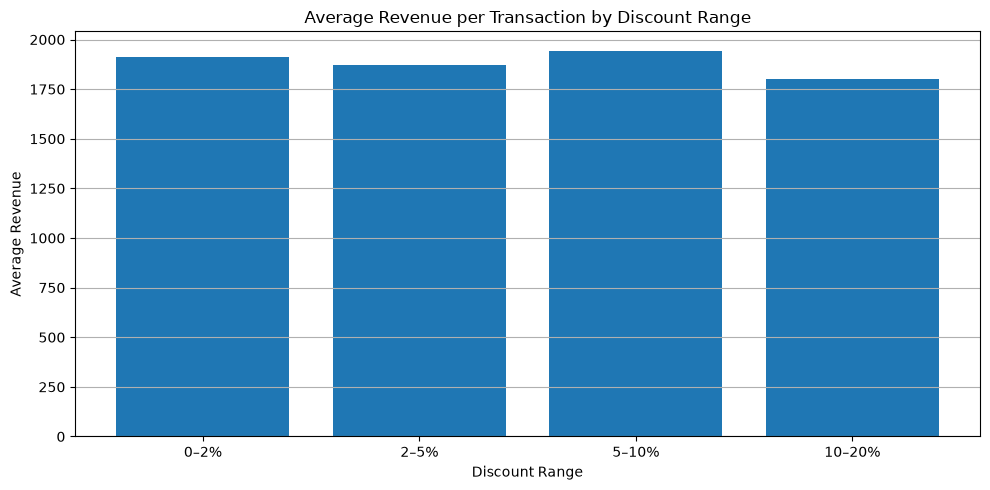

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    discount_analysis["discount_band"].astype(str),
    discount_analysis["average_revenue"]
)

plt.title("Average Revenue per Transaction by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Average Revenue")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [26]:
promotion_analysis = (
    df.groupby("promotion")[["revenue", "gross_profit", "net_profit"]]
      .agg(["sum", "mean", "count"])
)

print(promotion_analysis)

                revenue                       gross_profit              \
                    sum         mean   count           sum        mean   
promotion                                                                
0          3.756112e+08  1886.119391  199145  1.036558e+08  520.504143   
1          9.382625e+07  1850.214879   50711  2.588810e+07  510.502600   

                    net_profit                      
            count          sum        mean   count  
promotion                                           
0          199145  74846846.09  375.840951  199145  
1           50711  18695709.79  368.671684   50711  


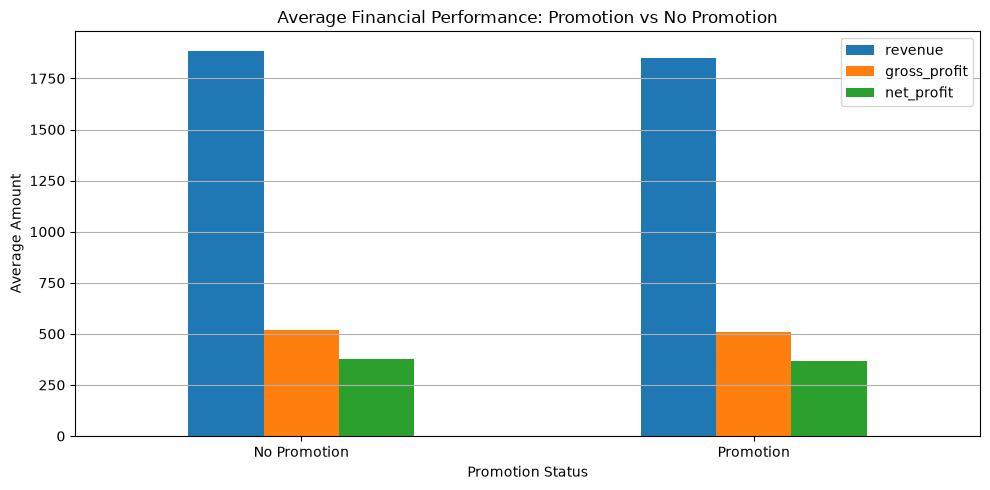

In [27]:
promotion_summary = (
    df.groupby("promotion")[["revenue", "gross_profit", "net_profit"]]
      .mean()
)

promotion_summary.index = ["No Promotion", "Promotion"]

promotion_summary.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Financial Performance: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Amount")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [28]:
price_revenue_corr = df["unit_price"].corr(df["revenue"])

print("Correlation between Unit Price and Revenue:",
      round(price_revenue_corr, 4))

Correlation between Unit Price and Revenue: 0.7216


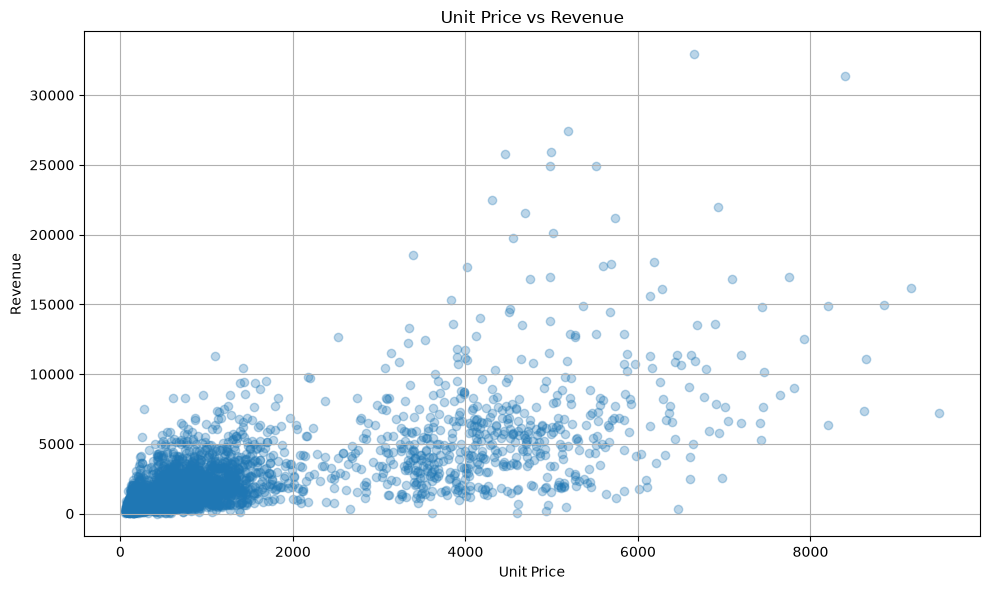

In [29]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df["unit_price"],
    sample_df["revenue"],
    alpha=0.3
)

plt.title("Unit Price vs Revenue")
plt.xlabel("Unit Price")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()

plt.show()

In [30]:
monthly_cashflow = (
    df.groupby(df["invoice_date"].dt.to_period("M"))
      .agg({
          "cash_inflow": "sum",
          "cash_outflow": "sum",
          "net_cash_flow": "sum"
      })
      .reset_index()
)

monthly_cashflow["invoice_date"] = (
    monthly_cashflow["invoice_date"].dt.to_timestamp()
)

print(monthly_cashflow.head())

  invoice_date  cash_inflow  cash_outflow  net_cash_flow
0   2022-01-01  13844780.66   11283984.93     2560795.73
1   2022-02-01  12538027.81   10122807.44     2415220.37
2   2022-03-01  14531335.59   11851441.70     2679893.89
3   2022-04-01  13708966.43   11167315.26     2541651.17
4   2022-05-01  13265596.77   10874193.94     2391402.83


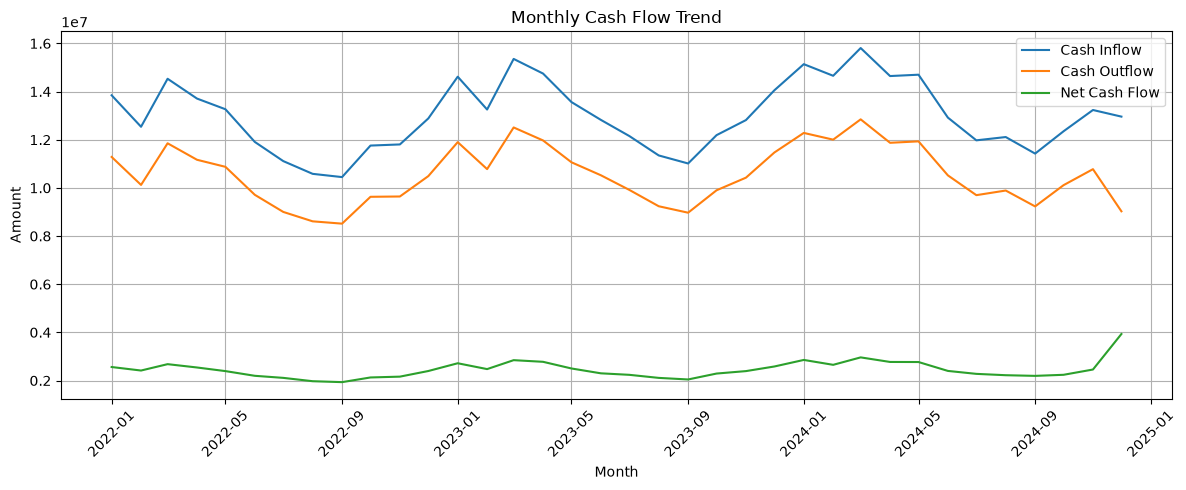

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cashflow["invoice_date"],
    monthly_cashflow["cash_inflow"],
    label="Cash Inflow"
)

plt.plot(
    monthly_cashflow["invoice_date"],
    monthly_cashflow["cash_outflow"],
    label="Cash Outflow"
)

plt.plot(
    monthly_cashflow["invoice_date"],
    monthly_cashflow["net_cash_flow"],
    label="Net Cash Flow"
)

plt.title("Monthly Cash Flow Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [32]:
positive_months = (monthly_cashflow["net_cash_flow"] > 0).sum()
negative_months = (monthly_cashflow["net_cash_flow"] < 0).sum()
zero_months = (monthly_cashflow["net_cash_flow"] == 0).sum()

print("Total months:", len(monthly_cashflow))
print("Positive cash-flow months:", positive_months)
print("Negative cash-flow months:", negative_months)
print("Zero cash-flow months:", zero_months)

print("\nAverage monthly net cash flow:",
      round(monthly_cashflow["net_cash_flow"].mean(), 2))

print("Minimum monthly net cash flow:",
      round(monthly_cashflow["net_cash_flow"].min(), 2))

print("Maximum monthly net cash flow:",
      round(monthly_cashflow["net_cash_flow"].max(), 2))

Total months: 36
Positive cash-flow months: 36
Negative cash-flow months: 0
Zero cash-flow months: 0

Average monthly net cash flow: 2457804.62
Minimum monthly net cash flow: 1933143.33
Maximum monthly net cash flow: 3931725.39


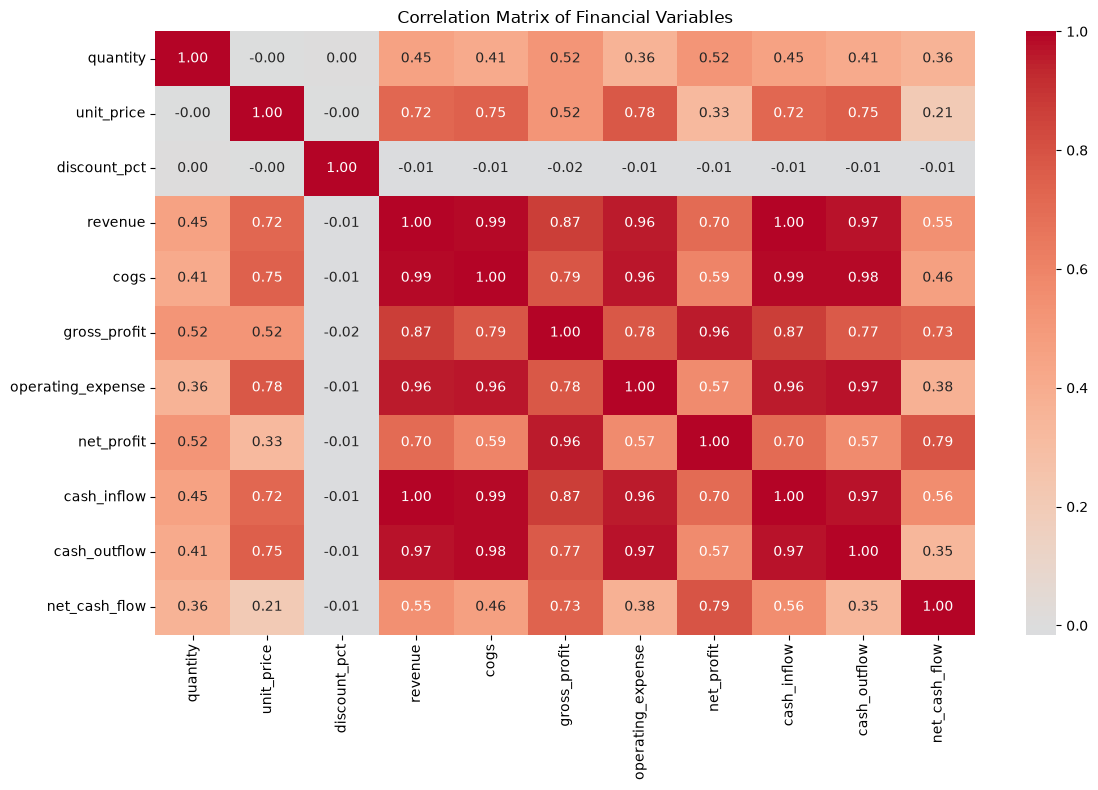

In [34]:
import seaborn as sns
correlation_columns = [
    "quantity",
    "unit_price",
    "discount_pct",
    "revenue",
    "cogs",
    "gross_profit",
    "operating_expense",
    "net_profit",
    "cash_inflow",
    "cash_outflow",
    "net_cash_flow"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial Variables")
plt.tight_layout()

plt.show()

# Business Insights

## 1. Revenue shows seasonal fluctuations
Monthly revenue varies considerably over time, with recurring periods of higher and lower sales. This indicates that seasonality should be considered when developing the revenue forecasting model.

## 2. Profit margins remain relatively stable
Despite fluctuations in monthly revenue, gross margin remains around 27–28% and net profit margin around 19–21%. This indicates relatively stable profitability efficiency over the analyzed period.

## 3. Regional performance is relatively balanced
Revenue is distributed fairly evenly across the five regions. South generates the highest revenue, while North generates the lowest, but regional profit margins are very similar.

## 4. Store A has the highest sales contribution
Store A generates substantially more revenue and profit than the other store types. However, profit margins across store types remain very similar, suggesting that the difference is primarily related to sales volume.

## 5. Product category has a major effect on profitability
Electronics generates the highest revenue but has the lowest net margin among the major categories. Clothing generates considerably less revenue but has the highest net margin. Therefore, revenue volume and profitability should be analyzed separately.

## 6. Regular customers contribute the most revenue
Regular customers generate the highest total revenue and net profit. Wholesale customers have a slightly higher net margin despite contributing less total revenue.

## 7. Unit price and quantity are associated with revenue
Unit price has a relatively strong positive correlation with revenue (0.72), while quantity has a moderate positive correlation (0.45). These variables may provide useful information for future forecasting models.

## 8. Discounts show little linear relationship with revenue
Discount percentage has almost zero correlation with revenue (-0.01). The analysis does not show a simple linear relationship between higher discounts and higher transaction revenue.

## 9. Promotions show only small differences in average transaction performance
Promoted transactions have slightly lower average revenue, gross profit and net profit than non-promoted transactions. However, this analysis is observational and does not establish that promotions cause lower financial performance.

## 10. Cash flow remains consistently positive
All 36 analyzed months have positive net cash flow. Average monthly net cash flow is approximately $2.46 million, indicating consistent positive cash generation within this dataset.

## 11. Financial variables are strongly interconnected
Revenue has strong relationships with COGS, gross profit, operating expenses and cash-flow variables. These relationships are expected from the financial structure of the dataset but must be considered carefully when selecting features for forecasting models.

